# Eval Results Viewer
Load JSON results from one or more eval directories, aggregate, and visualise by task.

In [14]:
# ── Configuration ─────────────────────────────────────────────────────────────
# List as many eval subdirs as you like — results are merged.
STABLEWM_HOME = "/lustre/fswork/projects/rech/yil/ugy35qd/.stable_worldmodel"

EVAL_DIRS = [
    #f"{STABLEWM_HOME}/eval/43341",
     #f"{STABLEWM_HOME}/eval/49822",  # add more job IDs here
     f"{STABLEWM_HOME}/eval/71778", # wm
     f"{STABLEWM_HOME}/eval/71591", # wm
     f"{STABLEWM_HOME}/eval/2111995", # ar lstm    
]

# Optional: rename models for display. Keys = checkpoint name, values = display label.
MODEL_LABELS = {
    # "scenario3_sensor_w1_H50_v3": "JEPA w=1 H=50",
    # "scenario3_sensor_w1_H50_S5": "JEPA w=1 H=50 S=5",
}

In [15]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "serif", "font.size": 10,
    "axes.titlesize": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.8, "figure.dpi": 120,
})

COMPONENT_SHORT = {
    "deg_CmpBst_s_mapEff_in": "Bst/Eff",
    "deg_CmpBst_s_mapWc_in":  "Bst/Wc",
    "deg_CmpFan_s_mapEff_in": "Fan/Eff",
    "deg_CmpFan_s_mapWc_in":  "Fan/Wc",
    "deg_CmpH_s_mapEff_in":   "HPC/Eff",
    "deg_CmpH_s_mapWc_in":    "HPC/Wc",
    "deg_TrbH_s_mapEff_in":   "HPT/Eff",
    "deg_TrbH_s_mapWc_in":    "HPT/Wc",
    "deg_TrbL_s_mapEff_in":   "LPT/Eff",
    "deg_TrbL_s_mapWc_in":    "LPT/Wc",
}

def label(model):
    return MODEL_LABELS.get(model, model)

# ── Load all JSONs ─────────────────────────────────────────────────────────────
all_results = []
for d in EVAL_DIRS:
    for jf in sorted(Path(d).glob("*.json")):
        if jf.name == "summary.json":
            continue
        with open(jf) as f:
            res = json.load(f)
        res["_source_dir"] = str(d)
        all_results.append(res)

print(f"Loaded {len(all_results)} result(s):")
for r in all_results:
    status = "ERROR: " + r['error'][:60] if "error" in r else "ok"
    print(f"  [{status}]  {r['name']}  (obs_window={r.get('obs_window_size','?')}, params={r.get('n_params','?'):,})")

Loaded 11 result(s):
  [ok]  scenario3_sensor_w1_H50_S5  (obs_window=1, params=825,940)
  [ok]  scenario3_sensor_w1_H50_v3  (obs_window=1, params=825,940)
  [ok]  scenario3_sensor_w5_H50_S5  (obs_window=5, params=876,500)
  [ok]  scenario3_sensor_w10_H10_S10  (obs_window=10, params=874,260)
  [ok]  scenario3_sensor_w1_H100_v3  (obs_window=1, params=829,140)
  [ok]  scenario3_sensor_w1_H10_S10  (obs_window=1, params=823,380)
  [ok]  ar_lstm_h1  (obs_window=1, params=1,133,460)
  [ok]  ar_lstm_h10  (obs_window=1, params=1,133,460)
  [ok]  ar_lstm_h50  (obs_window=1, params=1,133,460)
  [ok]  jepa_w1_h100  (obs_window=1, params=829,140)
  [ok]  jepa_w1_h50  (obs_window=1, params=825,940)


## Model overview

In [16]:
rows = []
for r in all_results:
    if "error" in r:
        continue
    t1 = r.get("task1_hi") or {}
    # best mean R² across seq_lens
    t1_r2 = max((v.get("__mean__", {}).get("r2", float("nan")) for v in t1.values()), default=float("nan"))
    t1_sl = next((sl for sl, v in t1.items() if v.get("__mean__", {}).get("r2", -999) == t1_r2), "-")

    t2 = r.get("task2_delta_hi") or {}
    t2_r2 = max((v.get("__mean__", {}).get("r2", float("nan")) for v in t2.values()), default=float("nan"))

    alarm = (r.get("task2b_alarm") or {}).get("K20") or {}
    t3 = r.get("task3_forecast") or {}
    mr = t3.get("mean_rmse_all", [])
    gap = t3.get("mean_rmse_gap", [])

    rows.append({
        "Model": label(r["name"]),
        "obs_window": r.get("obs_window_size", "?"),
        "n_params": r.get("n_params", "?"),
        "T1 R² (best sl)": f"{t1_r2:.3f} ({t1_sl})",
        "T2 R² (best sl)": f"{t2_r2:.3f}",
        "Alarm AUC@K20": f"{alarm.get('auc', float('nan')):.3f}" if alarm.get('auc') is not None else "—",
        "T3 RMSE τ=1": f"{mr[0]:.4f}" if mr else "—",
        "T3 RMSE τ=10": f"{mr[9]:.4f}" if len(mr) > 9 else "—",
        "T3 gap τ=10": f"{gap[9]:+.4f}" if len(gap) > 9 else "—",
    })

overview = pd.DataFrame(rows).set_index("Model")
overview

,obs_window,n_params,T1 R² (best sl),T2 R² (best sl),Alarm AUC@K20,T3 RMSE τ=1,T3 RMSE τ=10,T3 gap τ=10
Model,,,,,,,,
scenario3_sensor_w1_H50_S5,1,825940,0.796 (sl10),-0.007,0.500,0.0125,0.0084,+0.0008
scenario3_sensor_w1_H50_v3,1,825940,0.824 (sl1),-0.004,0.500,0.0144,0.0227,+0.0014
scenario3_sensor_w5_H50_S5,5,876500,0.826 (sl1),-0.004,0.500,0.0173,0.0194,+0.0013
scenario3_sensor_w10_H10_S10,10,874260,0.845 (sl1),-0.004,0.500,0.0044,0.0057,-0.0010
scenario3_sensor_w1_H100_v3,1,829140,0.790 (sl1),-0.006,0.500,0.0114,0.0111,+0.0010
scenario3_sensor_w1_H10_S10,1,823380,0.812 (sl1),-0.006,0.500,0.0175,0.0079,-0.0019
ar_lstm_h1,1,1133460,0.844 (sl10),-0.004,0.500,0.0027,0.0039,+0.0035
ar_lstm_h10,1,1133460,0.846 (sl1),-0.009,0.500,0.0023,0.0034,+0.0028
ar_lstm_h50,1,1133460,0.849 (sl10),-0.002,0.500,0.0021,0.0029,+0.0031


## Task 1 — HI State Estimation
### Mean R² / RMSE / Pearson-r across seq_lens

In [17]:
t1_rows = []
for r in all_results:
    if "error" in r:
        continue
    for sl_tag, dims in (r.get("task1_hi") or {}).items():
        mean = dims.get("__mean__", {})
        t1_rows.append({
            "model": label(r["name"]),
            "seq_len": sl_tag,
            "R²":        mean.get("r2",        float("nan")),
            "RMSE":      mean.get("rmse",       float("nan")),
            "Pearson-r": mean.get("pearson_r",  float("nan")),
        })

t1_df = pd.DataFrame(t1_rows)
display(t1_df.pivot(index="model", columns="seq_len", values=["R²", "RMSE", "Pearson-r"]).round(6))

R²                          RMSE  \
seq_len                            sl1      sl10      sl50       sl1   
model                                                                  
ar_lstm_h1                    0.827220  0.843862  0.833482  0.002016   
ar_lstm_h10                   0.846314  0.788844  0.786844  0.001872   
ar_lstm_h50                   0.838356  0.849097  0.834782  0.001944   
jepa_w1_h100                  0.842648  0.849108  0.821513  0.001907   
jepa_w1_h50                   0.810159  0.869188  0.859062  0.002093   
scenario3_sensor_w10_H10_S10  0.845091  0.789334  0.801835  0.001893   
scenario3_sensor_w1_H100_v3   0.790122  0.765664  0.785444  0.002243   
scenario3_sensor_w1_H10_S10   0.812268  0.796205  0.787100  0.002120   
scenario3_sensor_w1_H50_S5    0.786919  0.795923  0.756771  0.002233   
scenario3_sensor_w1_H50_v3    0.824470  0.795218  0.823250  0.001992   
scenario3_sensor_w5_H50_S5    0.826463  0.760205  0.783449  0.001996   

                                                 Pearson-r                      
seq_len                           sl10      sl50       sl1      sl10      sl50  
model                                                                           
ar_lstm_h1                    0.001883  0.001952  0.913520  0.919979  0.914840  
ar_lstm_h10                   0.002259  0.002252  0.921827  0.891811  0.889665  
ar_lstm_h50                   0.001860  0.001942  0.917862  0.922940  0.915114  
jepa_w1_h100                  0.001859  0.002028  0.920898  0.923177  0.908673  
jepa_w1_h50                   0.001704  0.001762  0.903016  0.933560  0.928629  
scenario3_sensor_w10_H10_S10  0.002202  0.002112  0.922028  0.894749  0.897891  
scenario3_sensor_w1_H100_v3   0.002386  0.002208  0.894982  0.883241  0.892395  
scenario3_sensor_w1_H10_S10   0.002203  0.002236  0.903729  0.896431  0.892409  
scenario3_sensor_w1_H50_S5    0.002209  0.002428  0.893906  0.896594  0.882358  
scenario3_sensor_w1_H50_v3    0.002203  0.001978  0.911447  0.896110  0.909278  
scenario3_sensor_w5_H50_S5    0.002424  0.002221  0.911585  0.882927  0.890416

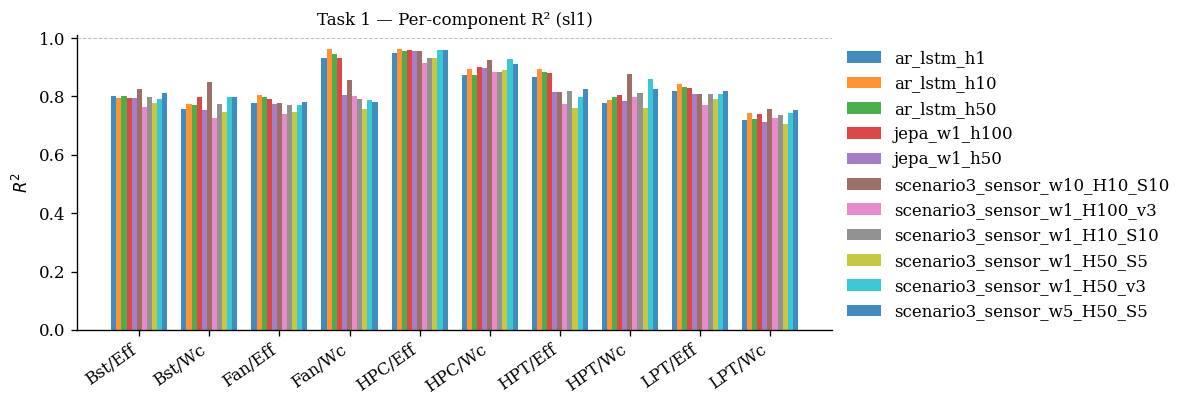

In [20]:
# Per-component R² for a chosen seq_len
SEQ_LEN = "sl1"   # change to "sl10" or "sl50" if available

comp_rows = []
for r in all_results:
    if "error" in r:
        continue
    dims = (r.get("task1_hi") or {}).get(SEQ_LEN, {})
    for comp, metrics in dims.items():
        if comp == "__mean__":
            continue
        comp_rows.append({
            "model": label(r["name"]),
            "component": COMPONENT_SHORT.get(comp, comp),
            "R²": metrics.get("r2", float("nan")),
        })

comp_df = pd.DataFrame(comp_rows)
models  = comp_df["model"].unique()
comps   = list(COMPONENT_SHORT.values())
x = np.arange(len(comps))
width = 0.8 / max(len(models), 1)

fig, ax = plt.subplots(figsize=(10, 3.5))
for i, m in enumerate(sorted(models)):
    sub = comp_df[comp_df["model"] == m].set_index("component")["R²"]
    vals = [float(sub.get(c, np.nan)) for c in comps]
    ax.bar(x + (i - len(models)/2 + 0.5) * width, vals, width, label=m, alpha=0.85)

ax.axhline(1.0, color="grey", lw=0.6, ls="--", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(comps, rotation=35, ha="right")
ax.set_ylabel("$R^2$"); ax.set_title(f"Task 1 — Per-component R² ({SEQ_LEN})")
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

## Task 2 — Degradation Velocity (ΔHI)
### Mean metrics across seq_lens

In [21]:
t2_rows = []
for r in all_results:
    if "error" in r:
        continue
    for sl_tag, dims in (r.get("task2_delta_hi") or {}).items():
        mean = dims.get("__mean__", {})
        t2_rows.append({
            "model": label(r["name"]),
            "seq_len": sl_tag,
            "R²":        mean.get("r2",        float("nan")),
            "RMSE":      mean.get("rmse",       float("nan")),
            "Pearson-r": mean.get("pearson_r",  float("nan")),
        })

t2_df = pd.DataFrame(t2_rows)
if not t2_df.empty:
    display(t2_df.pivot(index="model", columns="seq_len", values=["R²", "RMSE", "Pearson-r"]).round(4))
else:
    print("No Task 2 results (run with --tasks 1 2 or all)")

R²                 RMSE           Pearson-r  \
seq_len                          sl1    sl10    sl50  sl1 sl10 sl50       sl1   
model                                                                           
ar_lstm_h1                   -0.0123 -0.0134 -0.0043  0.0  0.0  0.0       NaN   
ar_lstm_h10                  -0.0090 -0.0109 -0.0155  0.0  0.0  0.0       NaN   
ar_lstm_h50                  -0.0160 -0.0089 -0.0023  0.0  0.0  0.0       NaN   
jepa_w1_h100                 -0.0210 -0.0097 -0.0098  0.0  0.0  0.0       NaN   
jepa_w1_h50                  -0.0404 -0.0115 -0.0119  0.0  0.0  0.0       NaN   
scenario3_sensor_w10_H10_S10 -0.0065 -0.0044 -0.0073  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H100_v3  -0.0071 -0.0060 -0.0061  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H10_S10  -0.0082 -0.0058 -0.0080  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H50_S5   -0.0105 -0.0075 -0.0073  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H50_v3   -0.0064 -0.0079 -0.0042  0.0  0.0  0.0       NaN   
scenario3_sensor_w5_H50_S5   -0.0072 -0.0043 -0.0088  0.0  0.0  0.0       NaN   

                                        
seq_len                      sl10 sl50  
model                                   
ar_lstm_h1                    NaN  NaN  
ar_lstm_h10                   NaN  NaN  
ar_lstm_h50                   NaN  NaN  
jepa_w1_h100                  NaN  NaN  
jepa_w1_h50                   NaN  NaN  
scenario3_sensor_w10_H10_S10  NaN  NaN  
scenario3_sensor_w1_H100_v3   NaN  NaN  
scenario3_sensor_w1_H10_S10   NaN  NaN  
scenario3_sensor_w1_H50_S5    NaN  NaN  
scenario3_sensor_w1_H50_v3    NaN  NaN  
scenario3_sensor_w5_H50_S5    NaN  NaN

## Task 2b — Maintenance Alarm

In [22]:
alarm_rows = []
for r in all_results:
    if "error" in r:
        continue
    for k_str, metrics in (r.get("task2b_alarm") or {}).items():
        if not metrics:
            continue
        alarm_rows.append({
            "model":   label(r["name"]),
            "horizon": k_str,
            "AUC":     metrics.get("auc"),
            "Avg Prec": metrics.get("avg_precision"),
            "F1":      metrics.get("f1"),
        })

alarm_df = pd.DataFrame(alarm_rows)
if not alarm_df.empty:
    display(alarm_df.pivot(index="model", columns="horizon", values=["AUC", "Avg Prec", "F1"]).round(3))
else:
    print("No Task 2b results")

AUC                Avg Prec                      \
horizon                       K10 K100  K20  K50      K10   K100   K20    K50   
model                                                                           
ar_lstm_h1                    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
ar_lstm_h10                   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
ar_lstm_h50                   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
jepa_w1_h100                  0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
jepa_w1_h50                   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w10_H10_S10  0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H100_v3   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H10_S10   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H50_S5    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H50_v3    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w5_H50_S5    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   

                                 F1                       
horizon                         K10   K100    K20    K50  
model                                                     
ar_lstm_h1                    0.049  0.403  0.096  0.224  
ar_lstm_h10                   0.049  0.403  0.096  0.224  
ar_lstm_h50                   0.049  0.403  0.096  0.224  
jepa_w1_h100                  0.049  0.403  0.096  0.224  
jepa_w1_h50                   0.049  0.403  0.096  0.224  
scenario3_sensor_w10_H10_S10  0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H100_v3   0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H10_S10   0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H50_S5    0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H50_v3    0.049  0.403  0.096  0.224  
scenario3_sensor_w5_H50_S5    0.049  0.403  0.096  0.224

## Task 3 — Latent Forecasting
### RMSE(τ) curves — clean / event / gap

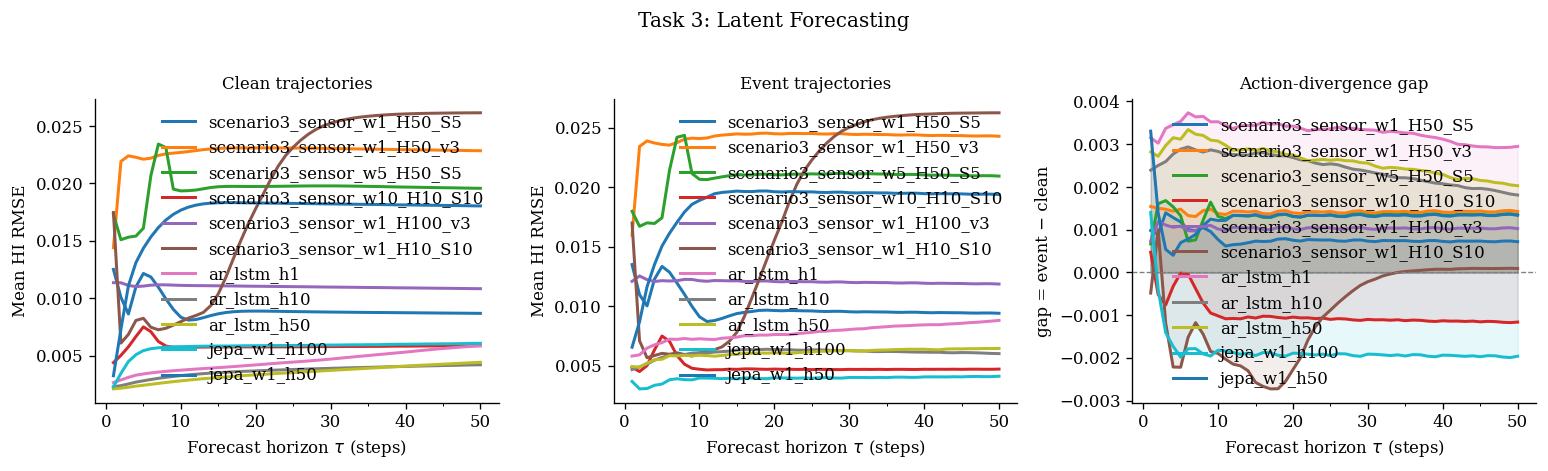

In [23]:
t3_results = [(label(r["name"]), r["task3_forecast"]) for r in all_results
              if "error" not in r and r.get("task3_forecast")]

if not t3_results:
    print("No Task 3 results (run with --tasks 1 2 3 or all)")
else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (name, t3) in enumerate(t3_results):
        col = prop_cycle[i % len(prop_cycle)]
        tau = np.arange(1, len(t3["mean_rmse_all"]) + 1)
        axes[0].plot(tau, t3["mean_rmse_clean"], color=col, label=name)
        axes[1].plot(tau, t3["mean_rmse_event"], color=col, label=name)
        axes[2].plot(tau, t3["mean_rmse_gap"],   color=col, label=name)
        axes[2].fill_between(tau, 0, t3["mean_rmse_gap"], color=col, alpha=0.10)

    axes[2].axhline(0, color="grey", lw=0.8, ls="--")
    for ax, title, ylab in zip(
        axes,
        ["Clean trajectories", "Event trajectories", "Action-divergence gap"],
        ["Mean HI RMSE", "Mean HI RMSE", "gap = event − clean"],
    ):
        ax.set_xlabel(r"Forecast horizon $\tau$ (steps)")
        ax.set_ylabel(ylab); ax.set_title(title)
        ax.legend(frameon=False)
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))

    fig.suptitle("Task 3: Latent Forecasting", y=1.02)
    plt.tight_layout(); plt.show()

In [25]:
# Task 3 summary table at key horizons
t3_rows = []
for r in all_results:
    if "error" in r or not r.get("task3_forecast"):
        continue
    t3 = r["task3_forecast"]
    for tau in [1, 5, 10, 20, 50]:
        idx = tau - 1
        if idx >= len(t3.get("mean_rmse_all", [])):
            continue
        t3_rows.append({
            "model": label(r["name"]),
            "τ": tau,
            "RMSE (all)":   t3["mean_rmse_all"][idx],
            "RMSE (clean)": t3["mean_rmse_clean"][idx],
            "RMSE (event)": t3["mean_rmse_event"][idx],
            "gap":          t3["mean_rmse_gap"][idx],
        })

if t3_rows:
    display(pd.DataFrame(t3_rows).set_index(["model", "τ"]).round(5))
else:
    print("No Task 3 results")

RMSE (all)  RMSE (clean)  RMSE (event)  \
model                        τ                                            
scenario3_sensor_w1_H50_S5   1      0.01251       0.01251       0.01349   
                             5      0.01217       0.01215       0.01333   
                             10     0.00836       0.00834       0.00911   
                             20     0.00891       0.00887       0.00963   
                             50     0.00877       0.00868       0.00940   
scenario3_sensor_w1_H50_v3   1      0.01441       0.01440       0.01594   
                             5      0.02213       0.02211       0.02359   
                             10     0.02274       0.02270       0.02408   
                             20     0.02316       0.02309       0.02448   
                             50     0.02303       0.02285       0.02427   
scenario3_sensor_w5_H50_S5   1      0.01730       0.01730       0.01796   
                             5      0.01612       0.01610       0.01742   
                             10     0.01938       0.01934       0.02065   
                             20     0.01980       0.01973       0.02103   
                             50     0.01975       0.01957       0.02092   
scenario3_sensor_w10_H10_S10 1      0.00439       0.00438       0.00485   
                             5      0.00750       0.00750       0.00748   
                             10     0.00569       0.00571       0.00469   
                             20     0.00571       0.00575       0.00471   
                             50     0.00574       0.00587       0.00470   
scenario3_sensor_w1_H100_v3  1      0.01135       0.01135       0.01208   
                             5      0.01107       0.01105       0.01213   
                             10     0.01114       0.01111       0.01213   
                             20     0.01109       0.01104       0.01206   
                             50     0.01096       0.01083       0.01185   
scenario3_sensor_w1_H10_S10  1      0.01746       0.01746       0.01698   
                             5      0.00822       0.00824       0.00603   
                             10     0.00791       0.00795       0.00606   
                             20     0.01770       0.01781       0.01553   
                             50     0.02617       0.02615       0.02624   
ar_lstm_h1                   1      0.00267       0.00265       0.00580   
                             5      0.00348       0.00340       0.00693   
                             10     0.00386       0.00373       0.00725   
                             20     0.00443       0.00418       0.00761   
                             50     0.00631       0.00585       0.00880   
ar_lstm_h10                  1      0.00229       0.00228       0.00467   
                             5      0.00287       0.00280       0.00569   
                             10     0.00336       0.00325       0.00608   
                             20     0.00386       0.00367       0.00636   
                             50     0.00447       0.00419       0.00601   
ar_lstm_h50                  1      0.00212       0.00210       0.00492   
                             5      0.00249       0.00241       0.00553   
                             10     0.00292       0.00279       0.00587   
                             20     0.00352       0.00332       0.00608   
                             50     0.00472       0.00441       0.00644   
jepa_w1_h100                 1      0.00228       0.00227       0.00367   
                             5      0.00541       0.00543       0.00345   
                             10     0.00573       0.00577       0.00395   
                             20     0.00578       0.00586       0.00397   
                             50     0.00585       0.00607       0.00410   
jepa_w1_h50                  1      0.00325       0.00324       0.00654   
                             5      0.01436       0.01435 

## Task 1 — R² vs seq_len (all models)

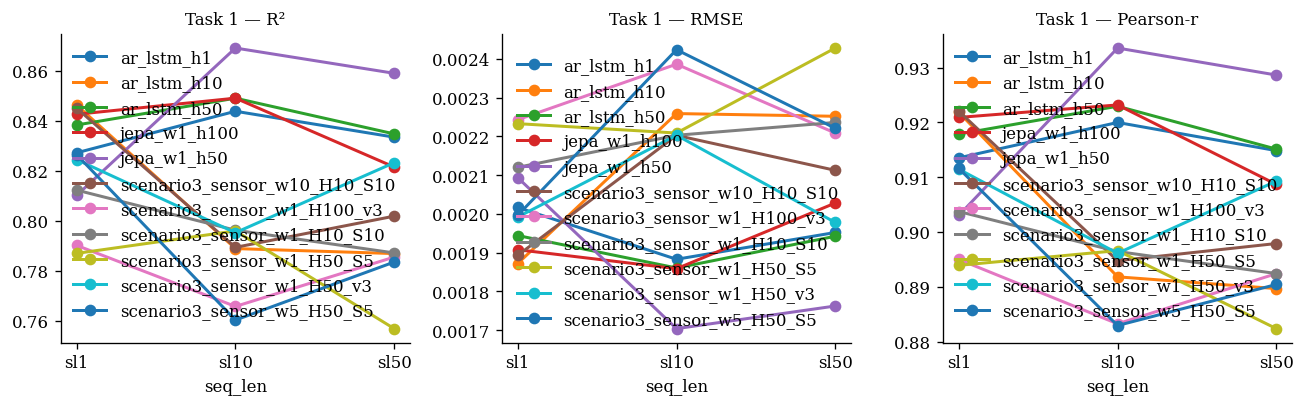

In [26]:
if not t1_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for metric, ax in zip(["R²", "RMSE", "Pearson-r"], axes):
        for i, m in enumerate(sorted(t1_df["model"].unique())):
            sub = t1_df[t1_df["model"] == m].sort_values("seq_len")
            ax.plot(sub["seq_len"], sub[metric], marker="o",
                    color=prop_cycle[i % len(prop_cycle)], label=m)
        ax.set_title(f"Task 1 — {metric}")
        ax.set_xlabel("seq_len")
        ax.legend(frameon=False)

    plt.tight_layout(); plt.show()